In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
# sys.path.append('../../../')
# from mount_drive import mount_s_drive

In [2]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
sys.path.insert(0, dir1)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from sklearn.feature_selection import VarianceThreshold

from PMAPUtil import *

In [3]:
columns = [
    # Demographics
    "gender",
    "age",

    # Neurologic
    "first_mGCS",
    "flo_first_r_cpn_glasgow_coma_scale_score",

    # Vital Signs – First
    "flo_first_bp_systolic",
    "flo_first_bp_diastolic",
    "flo_first_r_map",
    "flo_first_temperature",
    "flo_first_r_ed_pre-arrival_pulse_(heart_rate)",
    "flo_first_r_fio2",
    "flo_first_r_spo2:fio2_covid-19_calculation",

    # Severity Scores
    "flo_first_r_sofa_score",

    "flo_first_r_jhm_ip_sofa_cv_score",
    "flo_first_r_jhm_ip_sofa_cns_score",
    "flo_first_r_jhm_ip_sofa_coagulation_score",
    "flo_first_r_jhm_ip_sofa_liver_score",
    "flo_first_r_jhm_ip_sofa_renal_score",
    
    # Respiratory / Oxygenation
    "flo_first_r_jhm_ip_pao2/fio2",
    "flo_first_r_jhm_ip_rt_vent_fio2_(%)",
    "flo_first_r_jhm_ip_rt_conv._vent._high_respiratory_rate",
    "flo_first_r_jhm_ip_rt_conv._vent._low_respiratory_rate",

    # Hemodynamics / Shock
    "flo_first_r_norepinephrine_volume",

    # Renal / Urine Output
    "flo_first_jhm_ip_4hr_urine_output_goal_(12ml/kg)_is_at_least",
    "flo_first_jhm_ip_4hr_urine_output_goal_(2ml/kg)_is_at_least",

    # Anthropometrics
    "flo_first_r_bmi",

    # Labs – First
    "lab_first_troponin",
    "lab_first_creatinine,whole_blood",
    "lab_first_lactate",
    "lab_first_glucose,whole_blood",
    "lab_first_potassium,whole_blood",
    "lab_first_sodium,whole_blood",
    "lab_first_hemoglobin,total,whole_blood",
    "lab_first_aptt",

    'hypothermia',
     'asystole',
     'pea',
     'cardiopulmonary arrest w/ resuscitation',
     'VF'
]
columns = ['lab_first_platelet_function_test',
 'flo_r_ed_vitals_assessment_timer_Mental Status Change',
 'flo_r_ed_vitals_assessment_timer_bicarb givent',
 'flo_r_an_red_screen_monitor_Calcium and bicarb given IV',
 'lab_first_calcium,_serum',
 'lab_first_calcium,_ionized,_whole_blood',
 'lab_first_creatine_kinase_(ck)',
 'lab_first_sun/creatinine_ratio',
 'lab_first_d-dimer,_quantitative',
 'lab_first_vitamin_d_(25-hydroxy)_total',
 'flo_first_r_fio2',
 'flo_first_r_an_fio2',
 'lab_first_glucose,_blood-_poc',
 'lab_first_glucose,_pleural_fluid',
 'lab_first_hemoglobin',
 'lab_first_hemoglobin_a1c',
 'lab_first_poct_epoc_lactate',
 'lab_first_poct_istat_lactate',
 'flo_first_r_blood_glucose_meter',
 'lab_first_complete_blood_count_(cbc)_+_auto_diff',
 'lab_first_lipase',
 'flo_first_r_jhm_passes',
 'lab_first_magnesium',
 'lab_first_ige,_serum',
 'flo_first_r_paco2',
 'flo_first_r_pao2',
 'flo_first_r_pao2',
 'flo_first_r_paco2',
 'flo_first_r_resp_ph',
 'lab_first_ph,_pleural_fluid',
 'lab_first_platelet_count',
 'lab_first_platelet_(citrate)_count',
 'lab_first_potassium',
 'lab_first_tryptase',
 'lab_first_total_protein_(body_fluid)',
 'lab_first_protein,_peritoneal_fluid',
 'lab_first_sodium',
 'lab_first_sodium,whole_blood',
 'flo_first_r_perf_venous_temp',
 'flo_first_r_cv_mac_blood_temp',
 'lab_first_prothrombin_time_+_inr',
 'lab_first_prothrombin_time,superstat',
 'lab_first_troponin',
 'lab_first_stroke_troponin',
 'flo_first_r_pao2',
 'flo_first_r_sao2',
 'lab_first_troponin',
 'lab_first_stroke_troponin',
 'flo_first_r_jh_blood_units_for_calculation',
 'flo_first_r_ip_blood_administration_volume',
 'flo_first_r_cerebral_perfusion_pressure',
 'flo_first_r_jhm_perf_cerebral_perfusion_temp',
 'flo_r_ip_fall_risk_category_Pos',
 'flo_r_ip_fall_risk_category_Voice',
 'death_at_disch',
 'flo_r_an_red_screen_monitor_Asytole - Brady at 30- Asystole - PEA - Asystole',
 'flo_r_jhm_ip_rt_observed_i:e_DC med31 - 229102',
 'death_at_disch',
 'flo_first_r_ecg_lead2_st',
 'flo_first_r_ecg_lead1_st',
 'flo_r_ed_ecg_proc_md_name_0-No mobility issues',
 'flo_r_ed_ecg_proc_md_name_Gabor Kelen',
 'flo_first_r_neck_2nd_degree_burn',
 'flo_first_r_head_3rd_degree_burn',
 'flo_first_emesis',
 'lab_first_ferritin',
 'lab_first_ferritin',
 'flo_first_emesis',
 'flo_first_r_right_buttock_3rd_degree_burn',
 'flo_r_jhm_ed_ambulance_run_Right brachial',
 'flo_first_r_left_buttock_2nd_degree_burn',
 'flo_r_ed_vitals_assessment_timer_Heart block',
 'flo_r_ed_ecg_proc_md_name_Tan',
 'flo_first_r_ecg_lead3_st',
 'flo_r_ed_ecg_proc_md_name_Flushed',
 'flo_first_r_ecg_lead1_st',
 'flo_first_*old_r_jhm_ip_qtc_interval',
 'flo_first_r_jhm_ip_qtc_ainterval_(sec)',
 'flo_r_ed_ecg_proc_md_name_Tara RN',
 'flo_r_ed_ecg_proc_md_name_Continuously',
 'flo_first_r_resp_vt_set/target_ml',
 'flo_first_r_rt_vt_vent_spontaneous',
 'flo_first_r_ecg_lead3_st',
 'flo_first_r_ecg_lead1_st',
 'flo_first_r_ecg_lead3_st',
 'flo_first_r_ecg_lead2_st',
 'flo_jhm_ip_cuff_pressure_string_Tachycardia',
 'flo_r_ed_ecg_proc_md_name_Tammy Waldman ',
 'flo_r_ed_vitals_assessment_timer_Critical',
 'flo_first_anesthesia_temperature',
 'traumatic cardiac arrest',
 'death due to cardiac arrest',
 'flo_r_ed_vitals_assessment_timer_Original surgical dressing intact',
 'flo_r_jhh_ed_dispo_recommendation_text_cardiac surgery at bedside',
 'med_sodium_chloride_bolus',
 'flo_r_jhh_ed_dispo_recommendation_text_Pt with history of seizure and on suboxaone',
 'flo_first_bp_diastolic',
 'med_lidocaine',
 'flo_r_ed_pre-hospital_ekg_no cardiac activity on bedside echo',
 'flo_r_jhh_ed_dispo_supplemental_info_no cardiac motion on bedside echo',
 'flo_first_emesis',
 'ed_visit_yn',
 'flo_first_r_jhm_ip_sofa_renal_score',
 'lab_first_renal_function_panel',
 'lab_first_hemoglobin',
 'lab_first_hemoglobin_a1c',
 'flo_first_r_jhm_ip_cerebral_oximetry_right',
 'flo_first_r_cerebral_perfusion_pressure',
 'flo_first_r_pulmonary_vasclar_resistance_calc',
 'flo_first_r_pulmonary_capillary_wedge_pressure',
 'med_sodium_bicarbonate_infusion',
 'flo_first_intravenous_intake',
 'med_epinephrine_1_mg/ml',
 'med_epinephrine_0.1_mg/ml_injection_syringe',
 'med_epinephrine_1_mg/ml',
 'med_epinephrine_hcl_2_mg/100_ml',
 'med_epinephrine_0.1_mg/ml_injection_syringe',
 'med_epinephrine_infusion_4_mcg/ml_in_250_ml_d5w',
 'age',
 'flo_r_ed_jhh_plan_of_care_notes_Age > 65',
 'lab_first_platelet_(citrate)_count',
 'lab_first_platelet_function_test',
 'flo_first_r_dobutamine_volume',
 'flo_first_r_vasopressin_volume',
 'med_ondansetron_hcl',
 'death_at_disch',
 'flo_first_r_systemic_vascular_resistance_calc',
 'flo_r_jhm_ip_rt_observed_i:e_central line and arterial line to be placed per Dr. Risko. ',
 'flo_jhm_ip_cust_formula_fall_risk_0-No fall history w/in 6 months prior to admission',
 'flo_r_jhm_trews_session_manual_override_History of DM',
 'flo_r_ed_vitals_assessment_timer_bicarb givent',
 'flo_r_ip_rt_jhm_conv._vent_high_tv_plan for Ca, mag, bicarb, amio ',
 'flo_r_ed_vitals_assessment_timer_bicarb givent',
 'med_sodium_bicarbonate_8.4_%',
 'flo_first_r_bmi',
 'flo_first_haz_r_bmi_osa_screen',
 'cardiopulmonary arrest',
 'cardiopulmonary arrest w/ resuscitation',
 'traumatic cardiac arrest',
 'death due to cardiac arrest',
 'med_heparin',
 'lab_first_haptoglobin',
 'med_heparin',
 'flo_r_jhm_trews_version_1#',
 'med_heparin',
 'flo_r_jhm_trews_version_105',
 'med_heparin',
 'flo_r_jhm_trews_version_11',
 'med_heparin',
 'med_chlorhexidine_gluconate_0.12%',
 'med_heparin',
 'flo_r_jhm_trews_version_1:1.3',
 'med_heparin',
 'flo_r_ed_care_handoff_rn_14',
 'med_heparin',
 'flo_r_cam-icu_overall_Positional',
 'med_heparin',
 'flo_r_cam-icu_overall_Positional',
 'med_heparin',
 'lab_first_haptoglobin',
 'med_heparin',
 'lab_first_haptoglobin',
 'med_heparin',
 'flo_r_cam-icu_overall_Positional',
 'med_heparin',
 'flo_r_cam-icu_overall_Positional',
 'med_heparin',
 'flo_r_cam-icu_overall_Positional',
 'med_heparin',
 'flo_r_cam-icu_overall_Positional',
 'lab_first_ck_mb_reflex',
 'lab_first_urinalysis_with_reflex_culture',
 'lab_first_coagulation_screen',
 'flo_first_r_jhm_ip_sofa_coagulation_score',
 'flo_first_r_amiodarone_volume',
 'med_amiodarone_360_mg/200_ml',
 'flo_first_r_amiodarone_volume',
 'med_amiodarone_150_mg/100_ml',
 'lab_first_ck_mb_reflex',
 'lab_first_urinalysis_with_reflex_culture',
 'flo_r_provider_name_ Adult Neurosurgery - Low Risk',
 'flo_jhm_r_ed_electronic_triage_supplement_Low Risk - Paralysis/Completely Immobilized',
 'med_lidocaine',
 'med_famotidine',
 'med_lidocaine',
 'med_famotidine',
 'flo_r_an_red_screen_monitor_Atrial fibrillation',
 'flo_r_jhm_ip_rt_mech_vent_id_#_provider doing bedsaide ultrasound',
 'flo_r_an_red_screen_monitor_Atrial fibrillation',
 'flo_r_jhm_ip_rt_mech_vent_id_#_provider doing bedsaide ultrasound',
 'flo_first_pulse_ox_heart_rate',
 'flo_first_r_amb_fcc_assess',
 'flo_first_r_fio2',
 'flo_first_r_an_fio2',
 'flo_first_r_jhm_ip_rt_conv._vent._low_respiratory_rate',
 'flo_first_r_jhm_ip_rt_conv._vent._high_respiratory_rate',
 'flo_first_r_cpn_glasgow_coma_scale_score',
 'flo_first_r_cpn_glasgow_coma_scale_score_2',
 'flo_first_r_cpn_glasgow_coma_scale_score',
 'flo_first_r_cpn_glasgow_coma_scale_score_2',
 'flo_r_ed_jhh_plan_of_care_notes_Hypertension',
 'hypothermia',
 'hypothermia',
 'med_heparin',
 'flo_first_r_jhm_ip_sofa_liver_score',
 'flo_first_r_morse_fall_risk_score',
 'flo_first_r_jhm_ip_crrt_circuit_volume',
 'flo_first_r_l_thigh_circumference_(cm)',
 'flo_first_r_apache_temperature',
 'med_ondansetron_hcl',
 'cardiac arrest with successful resuscitation',
 'traumatic cardiac arrest',
 'flo_first_r_perf_gas_flow',
 'flo_first_r_ip_vent_flow_vcac',
 'flo_first_r_jhm_ad_masa_score',
 'flo_first_r_jhm_ip_icu_cards_scale_score',
 'med_morphine_10_mg/ml_soln_erx_5168',
 'med_morphine_10_mg/ml_injection_syringe',
 'flo_first_r_jhm_ip_impella_motor_current_mean',
 'flo_first_r_jhm_ip_impella_left_motor_current_mean',
 'death due to cardiac arrest',
 'traumatic cardiac arrest',
 'flo_first_r_an_agents_n2o_flow',
 'flo_first_r_jhm_an_perf_perfusion_flow',
 'med_norepinephrine_infusion_8_mg_/_250_ml_ns',
 'med_norepinephrine_infusion_16_mg_/_116_ml_ns',
 'flo_first_r_amb_fcc_assess',
 'flo_first_r_amb_fcc_total_time',
 'flo_first_r_fio2',
 'flo_first_r_sao2',
 'flo_r_jhm_trews_version_Irregular',
 'flo_r_jhm_ed_ambulance_run_49',
 'lab_first_lipase',
 'flo_r_jhm_trews_session_end_dtm_Zoll pads on pt.',
 'flo_first_r_lorazepam_volume',
 'med_lorazepam_2_mg/ml_injection_syringe',
 'flo_first_r_jhm_passes',
 'flo_r_jhm_rcp_time_Passive',
 'lab_first_pro-b_natriuretic_peptide',
 'lab_first_b-type_natriuretic_peptide',
 'flo_first_weight/scale',
 'flo_first_r_jhm_ip_weight_kg',
 'flo_first_r_pulmonary_vasclar_resistance_calc',
 'flo_first_r_pulmonary_capillary_wedge_pressure',
 'flo_first_r_ad_right_pupil_npi',
 'flo_first_r_ad_left_pupil_npi',
 'flo_first_r_total_burn_area',
 'lab_first_c-reactive_protein',
 'flo_first_r_ad_left_pupil_npi',
 'flo_first_*old_r_pupil_size_(mm)_left',
 'flo_first_r_total_burn_area',
 'lab_first_hiv1_rna_realtime_pcr',
 'traumatic cardiac arrest',
 'flo_first_r_cardiac_index',
 'lab_first_ck_mb_reflex',
 'lab_first_urinalysis_with_reflex_culture',
 'lab_first_ck_mb_reflex',
 'lab_first_urinalysis_with_reflex_culture',
 'traumatic cardiac arrest',
 'death due to cardiac arrest',
 'flo_first_*old_r_ed_sedation_narr_qt_interval',
 'lab_first_sedimentation_rate',
 'last_mGCS_time',
 'flo_first_pulse',
 'flo_first_r_an_spo2',
 'flo_first_r_cv_mac_spo2',
 'lab_first_hemoglobin_a1c',
 'flo_first_r_skin_braden_scale_score',
 'flo_first_height',
 'med_heparin',
 'flo_r_jhm_ed_dispo_acute_risk_cardiac arrest',
 'flo_r_jhm_trews_version_Incoming cardiac arrest',
 'flo_r_jhm_ed_dispo_acute_risk_cardiac arrest',
 'flo_r_jhm_ed_dispo_crit_risk_Pt arrived. Unwitnessed arrest, pt paraplegic, recent RLE surgery, heroin abuse',
 'flo_first_r_jhm_ip_temp_goal',
 'flo_first_r_jhm_ip_temp_goal_2',
 'flo_r_jhh_ip_rt_low_etco2_alarm_Verbal',
 'flo_r_ed_vitals_assessment_timer_Unable to return demo and/or verbal instructions',
 'flo_first_r_ip_vent_vt_low',
 'flo_first_r_ip_vent_vt_high',
 'osler_id',
 'asystole',
 'cardiopulmonary arrest',
 'cardiopulmonary arrest w/ resuscitation',
 'flo_first_r_sofa_score',
 'flo_first_r_jhm_ip_sofa_coagulation_score',
 'flo_first_r_jhm_ip_sofa_liver_score',
 'lab_first_hepatic_function_panel',
 'flo_r_provider_name_ Adult Neurosurgery - Low Risk',
 'flo_r_jhm_ed_fall_risk_custom_formula_Patient has stopped bleeding @ this time. Plan to have 6.0 cuffed tube placed. Neuro IR paged',
 'flo_first_r_jhm_ip_sofa_renal_score',
 'lab_first_renal_function_panel',
 'flo_first_r_jhm_ip_sofa_resp_score',
 'flo_first_r_sofa_score',
 'flo_first_r_sofa_score',
 'flo_first_r_jhm_ip_sofa_cv_score',
 'flo_first_r_sofa_score',
 'flo_first_r_jhm_ip_sofa_cv_score',
 'flo_first_r_sofa_score',
 'flo_first_r_jhm_ip_sofa_cv_score',
 'flo_first_r_pca_patient_dose_mg',
 'flo_r_jhm_ip_rt_i:e_2_Body tag and bag tag match patient ID band',
 'med_heparin',
 'lab_first_hematocrit',
 'flo_first_r_an_fio2',
 'flo_r_an_red_screen_monitor_Mary Carter',
 'flo_r_non-violent_describe_behaviors_Yes',
 'flo_first_r_an_fio2',
 'lab_first_blood_gases,pump_gas',
 'flo_first_r_jhm_ip_ecmo_pump_speed',
 'med_heparin',
 'med_chlorhexidine_gluconate_0.12%',
 'med_heparin',
 'flo_r_cam-icu_overall_ M16',
 'med_heparin',
 'flo_r_cam-icu_overall_Positional',
 'med_heparin',
 'med_chlorhexidine_gluconate_0.12%',
 'med_heparin',
 'med_dapsone_100_mg_tablet',
 'med_heparin',
 'flo_r_cam-icu_overall_BC19',
 'lab_first_stroke_aptt',
 'flo_r_ed_vitals_assessment_timer_shock  delivered contiuned cpr',
 'flo_first_r_cv_mac_av_hb_sa_value',
 'flo_first_r_cv_mac_av_hb_pa_value',
 'cardiopulmonary arrest',
 'traumatic cardiac arrest',
 'med_lidocaine',
 'med_famotidine',
 'hypothermia',
 'flo_first_anesthesia_temperature',
 'lab_first_thromboelastograph,_rapid-jhh_only',
 'lab_first_thromboelastograph_clotting_profile',
 'flo_first_r_pt_treatment_time',
 'flo_first_r_jhh_post-treatment_rr',
 'hypothermia',
 'asystole',
 'pea',
 'cardiopulmonary arrest w/ resuscitation',
 'VF']

In [4]:
# myPredictorsDf.columns

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
# death_at_disch hypothermia 
def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('PMAP_Predictors2.csv')

    # top_corr = pd.read_csv('top_correlations.csv')
    # columns_to_drop = top_corr[top_corr['hypothermia'].abs() > 0.7]['Unnamed: 0'].tolist()
    columns_to_drop = []
    # Preprocessing
    myFilter = (myPredictorsDf['first_mGCS_time'] != myPredictorsDf['last_mGCS_time']) 
    myPredictorsDf.loc[myPredictorsDf['death_at_disch'] == 1, 'last_mGCS'] = 1
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'last_mGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.first_mGCS != 6)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x and 'dx_' == x[0:3]]

    # Get output data
    myXValue = myPredictorsDf.drop(columns=columns_to_drop+  myColumns + ['first_mGCS', 'last_mGCS_time', 'first_mGCS_time', 'LastMGCSPositive', 'last_mGCS', 'death_at_disch'])
    myXValue = myXValue
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [6]:
from econml.dml import CausalForestDML, SparseLinearDML, LinearDML, DML
from econml.orf import DMLOrthoForest
from econml.dr import LinearDRLearner
myTreatment = 'hypothermia'
myTreatmentColumn = myTreatment
myPredicted = 'death_at_disch'
myPredictorsDf, X_train_no_group, X_test_no_group, T_train, T_test, y_train, y_test =  \
                    getTrainTestFunctions(aPredictedColumn = myPredicted, 
                                            aTreatmentColumn = myTreatment, aTreatmentSplit = True, aSkipTemp = True, 
                                            aTestSize=.3) 
causal_forest = CausalForestDML(
    model_y= XGBClassifier(max_depth=5, n_estimators=50),  
    model_t= XGBClassifier(max_depth=2, n_estimators=20),    
    discrete_treatment=True,           
    discrete_outcome=True,
    verbose=2,
    n_jobs=-1
)

/home/mbranda1/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myCovariates = getCovariatePreprocessor([])
    myCovariates.set_output(transform="pandas")
    myVariance = getVariancePreprocessor([])
    myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor), ('imputer', myImputer)]

In [8]:
# X_train_no_group = X_train_no_group.loc[:, X_train_no_group.isnull().mean() < 0.9]
# X_test_no_group = X_test_no_group[X_train_no_group.columns]

columns_filter = np.unique([x for x in columns if x in X_train_no_group.columns])
X_train_no_group = X_train_no_group[columns_filter]
X_test_no_group = X_test_no_group[columns_filter]

In [9]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train_no_group))

In [10]:
myNewXTrain = pd.DataFrame(myPipeline.fit_transform(X_train_no_group), columns = myPipeline.get_feature_names_out())
myNewXTest = pd.DataFrame(myPipeline.transform(X_test_no_group), columns = myPipeline.get_feature_names_out())


In [11]:
causal_forest.fit(y_train, T_train, X=myNewXTrain, cache_values=True)
print(causal_forest.score(y_train, T_train, X=myNewXTrain))

CATE_pred = causal_forest.effect(myNewXTrain)

print(f'Feature importances {causal_forest.feature_importances_}')

print("Predicted CATE for test data:", CATE_pred[:10])

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  75 out of 100 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=64)]: Using backend ThreadingBackend w

0.05480519562126089
Feature importances [2.00579624e-02 1.80568891e-02 0.00000000e+00 1.69774395e-02
 0.00000000e+00 6.92724771e-03 1.22935884e-02 3.80406227e-02
 3.43156086e-02 0.00000000e+00 0.00000000e+00 0.00000000e+00
 5.96577348e-02 0.00000000e+00 2.20977177e-02 2.83337915e-02
 0.00000000e+00 2.04338012e-02 2.16458343e-02 3.74175192e-02
 4.22571018e-02 2.40100333e-02 6.89885450e-03 0.00000000e+00
 3.88055642e-02 0.00000000e+00 0.00000000e+00 1.32042004e-02
 2.09740592e-02 2.85297612e-02 2.25917705e-02 2.52430328e-02
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 3.05772091e-02 1.17735474e-02 2.34552405e-02
 2.70610415e-02 0.00000000e+00 3.18721891e-02 0.00000000e+00
 0.00000000e+00 2.60579669e-02 1.70887540e-02 2.04409315e-02
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.87842704e-02
 0.00000000e+00 2.94610546e-02 2.56856277e-02 0.00000000e+00
 0.00000000e+00 2.88029502e-02 2.77332866e-02 0.00000000e+00
 1.60797511e-02 0.00000000e+00 2.08481595e-02

[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished


[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished


propensity_model not found on model — refitting logistic regression.

GATES results — PMAP
 group  n  mean_cate      gate    ci_low  ci_high
     1 85  -0.013199  0.168135 -0.031907 0.368178
     2 85   0.024006  0.057729 -0.139895 0.255354
     3 84   0.044603 -0.069479 -0.274454 0.135495
     4 85   0.068510  0.131162 -0.075184 0.337508
     5 85   0.110732  0.221993  0.013848 0.430138

Interaction F-test: F=1.181, p=0.3184
Interpretation: No significant HTE captured (α=0.05)
Monotonicity (Spearman): ρ=0.300, p=0.6238


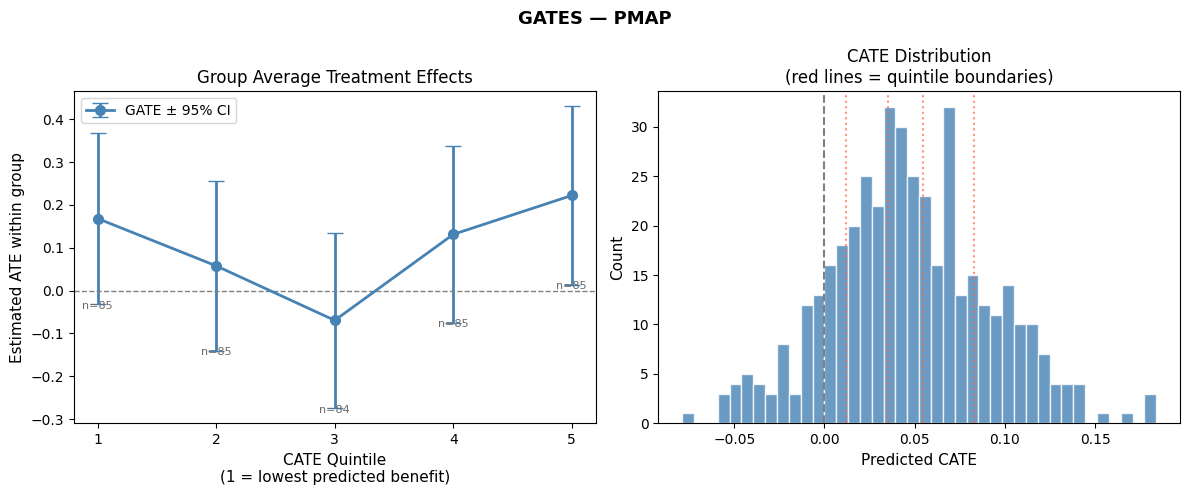

In [14]:
import numpy as np
import pandas as pd
from econml.dml import CausalForestDML
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

def run_gates(model: CausalForestDML, X: np.ndarray, Y: np.ndarray, T: np.ndarray, 
              n_groups: int = 5, dataset_name: str = "Dataset") -> pd.DataFrame:
    """
    Compute Group Average Treatment Effects (GATES) from a fitted CausalForestDML model.
    
    Parameters
    ----------
    model       : fitted CausalForestDML instance
    X           : covariates (n x p)
    Y           : outcome array (n,)
    T           : treatment array (n,) — binary 0/1
    n_groups    : number of quantile groups (default 5)
    dataset_name: label for plots/output
    
    Returns
    -------
    gates_df    : DataFrame with GATE estimate, CI, and n per group
    """

    # ------------------------------------------------------------------ #
    # 1. Get CATE estimates and propensity scores
    # ------------------------------------------------------------------ #
    cate = model.effect(X).flatten()

    # CausalForestDML exposes propensity via the fitted model internals
    try:
        ps = model.propensity_model.predict_proba(X)[:, 1]
    except AttributeError:
        # Fallback: refit a logistic regression for propensity
        print("propensity_model not found on model — refitting logistic regression.")
        ps_model = LogisticRegression(max_iter=1000)
        ps_model.fit(X, T)
        ps = ps_model.predict_proba(X)[:, 1]

    # Clip propensity to avoid extreme weights
    ps = np.clip(ps, 0.05, 0.95)

    # IPW weights
    ipw = np.where(T == 1, 1.0 / ps, 1.0 / (1.0 - ps))

    # ------------------------------------------------------------------ #
    # 2. Assign quantile groups based on predicted CATE
    # ------------------------------------------------------------------ #
    df = pd.DataFrame({
        "Y": Y,
        "T": T,
        "cate": cate,
        "ps": ps,
        "ipw": ipw,
    })

    df["group"] = pd.qcut(df["cate"], q=n_groups, labels=range(1, n_groups + 1))

    # ------------------------------------------------------------------ #
    # 3. Estimate ATE within each group via IPW-weighted regression
    # ------------------------------------------------------------------ #
    records = []
    for g in range(1, n_groups + 1):
        sub = df[df["group"] == g].copy()
        
        T_sub = sub["T"].values
        Y_sub = sub["Y"].values
        w_sub = sub["ipw"].values

        # WLS: Y ~ intercept + T, weighted by IPW
        X_reg = sm.add_constant(T_sub)
        wls = sm.WLS(Y_sub, X_reg, weights=w_sub).fit()

        gate    = wls.params[1]
        # With this:
        ci = wls.conf_int()
        ci_low  = ci[1, 0] if isinstance(ci, np.ndarray) else ci.iloc[1, 0]
        ci_high = ci[1, 1] if isinstance(ci, np.ndarray) else ci.iloc[1, 1]
        se      = wls.bse[1]

        records.append({
            "group":        g,
            "gate":         gate,
            "ci_low":       ci_low,
            "ci_high":      ci_high,
            "se":           se,
            "n":            len(sub),
            "mean_cate":    sub["cate"].mean(),
            "treated_frac": T_sub.mean(),
        })

    gates_df = pd.DataFrame(records)

    # ------------------------------------------------------------------ #
    # 4. Formal interaction test: Y ~ T * group_dummies (WLS)
    # ------------------------------------------------------------------ #
    df["group_int"] = df["group"].astype(int)

    # Build dummies and interactions on a clean copy
    # Replace the pd.get_dummies line with this:
    group_dummies = pd.get_dummies(df["group_int"], prefix="g", drop_first=True).astype(float)  
    group_dummy_cols = list(group_dummies.columns)

    # Add dummies to df first, then build interactions from actual columns
    df = pd.concat([df, group_dummies], axis=1)

    interact_cols = []
    for col in group_dummy_cols:
        interact_name = f"T_x_{col}"
        df[interact_name] = df["T"] * df[col]
        interact_cols.append(interact_name)

    design_cols = ["T"] + group_dummy_cols + interact_cols
    model_df = df[design_cols].astype(float)
    y_arr = df["Y"].astype(float).values
    w_arr = df["ipw"].astype(float).values

    X_full = sm.add_constant(model_df)
    full_model = sm.WLS(y_arr, X_full, weights=w_arr).fit()

    X_restricted = sm.add_constant(df[["T"] + group_dummy_cols].astype(float))
    restricted_model = sm.WLS(y_arr, X_restricted, weights=w_arr).fit()
    full_model = sm.WLS(df["Y"], X_full, weights=df["ipw"]).fit()

    X_restricted = sm.add_constant(df[["T"] + group_dummy_cols])
    restricted_model = sm.WLS(df["Y"], X_restricted, weights=df["ipw"]).fit()

    f_stat, f_pval, df_denom = full_model.compare_f_test(restricted_model)
    print(f"\n{'='*55}")
    print(f"GATES results — {dataset_name}")
    print(f"{'='*55}")
    print(gates_df[["group", "n", "mean_cate", "gate", "ci_low", "ci_high"]].to_string(index=False))
    print(f"\nInteraction F-test: F={f_stat:.3f}, p={f_pval:.4f}")
    print(f"Interpretation: {'Significant HTE captured' if f_pval < 0.05 else 'No significant HTE captured'} (α=0.05)")

    # ------------------------------------------------------------------ #
    # 5. Monotonicity test (Spearman rank correlation: group vs GATE)
    # ------------------------------------------------------------------ #
    rho, rho_p = stats.spearmanr(gates_df["group"], gates_df["gate"])
    print(f"Monotonicity (Spearman): ρ={rho:.3f}, p={rho_p:.4f}")

    # ------------------------------------------------------------------ #
    # 6. Plot
    # ------------------------------------------------------------------ #
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"GATES — {dataset_name}", fontsize=13, fontweight="bold")

    # Left: GATE per group with CI
    ax = axes[0]
    groups = gates_df["group"]
    ax.errorbar(
        groups, gates_df["gate"],
        yerr=[gates_df["gate"] - gates_df["ci_low"],
              gates_df["ci_high"] - gates_df["gate"]],
        fmt="o-", color="steelblue", capsize=6, linewidth=2, markersize=7,
        label="GATE ± 95% CI"
    )
    ax.axhline(0, linestyle="--", color="gray", linewidth=1)
    ax.set_xlabel("CATE Quintile\n(1 = lowest predicted benefit)", fontsize=11)
    ax.set_ylabel("Estimated ATE within group", fontsize=11)
    ax.set_title("Group Average Treatment Effects")
    ax.set_xticks(groups)
    ax.legend()

    # Annotate with n per group
    for _, row in gates_df.iterrows():
        ax.annotate(f"n={int(row['n'])}", xy=(row["group"], row["ci_low"] - 0.01),
                    ha="center", fontsize=8, color="dimgray")

    # Right: distribution of CATE estimates
    ax2 = axes[1]
    ax2.hist(cate, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    ax2.axvline(0, linestyle="--", color="gray")
    for bound in np.percentile(cate, np.linspace(0, 100, n_groups + 1)[1:-1]):
        ax2.axvline(bound, linestyle=":", color="tomato", alpha=0.7)
    ax2.set_xlabel("Predicted CATE", fontsize=11)
    ax2.set_ylabel("Count", fontsize=11)
    ax2.set_title("CATE Distribution\n(red lines = quintile boundaries)")

    plt.tight_layout()
    plt.savefig(f"gates_{dataset_name.lower().replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()

    gates_df["dataset"] = dataset_name
    gates_df["f_stat"] = f_stat
    gates_df["f_pval"] = f_pval
    gates_df["spearman_rho"] = rho
    gates_df["spearman_p"] = rho_p

    # Round for display
    display_df = gates_df[[
        "dataset", "group", "n", "mean_cate",
        "gate", "ci_low", "ci_high", "f_stat", "f_pval",
        "spearman_rho", "spearman_p"
    ]].copy()

    display_df = display_df.round({
        "mean_cate": 3,
        "gate": 3,
        "ci_low": 3,
        "ci_high": 3,
        "f_stat": 3,
        "f_pval": 4,
        "spearman_rho": 3,
        "spearman_p": 4,
    })

    # Format CI as single string for readability
    display_df["95% CI"] = (
        "[" + display_df["ci_low"].astype(str) +
        ", " + display_df["ci_high"].astype(str) + "]"
    )

    return display_df




gates_df = run_gates(causal_forest, myNewXTest, y_test, T_test, n_groups=5, dataset_name="PMAP")

In [15]:
gates_df.style.hide(axis='index')

dataset,group,n,mean_cate,gate,ci_low,ci_high,f_stat,f_pval,spearman_rho,spearman_p,95% CI
PMAP,1,85,-0.013000,0.168000,-0.032000,0.368000,1.181000,0.318400,0.300000,0.623800,"[-0.032, 0.368]"
PMAP,2,85,0.024000,0.058000,-0.140000,0.255000,1.181000,0.318400,0.300000,0.623800,"[-0.14, 0.255]"
PMAP,3,84,0.045000,-0.069000,-0.274000,0.135000,1.181000,0.318400,0.300000,0.623800,"[-0.274, 0.135]"
PMAP,4,85,0.069000,0.131000,-0.075000,0.338000,1.181000,0.318400,0.300000,0.623800,"[-0.075, 0.338]"
PMAP,5,85,0.111000,0.222000,0.014000,0.430000,1.181000,0.318400,0.300000,0.623800,"[0.014, 0.43]"


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _combine_x_w(X=None, W=None):
    """
    Reconstruct the design matrix used by econml first-stage nuisance models.
    """
    if X is None and W is None:
        raise ValueError("At least one of X or W must be provided.")
    if X is None:
        return np.asarray(W)
    if W is None:
        return np.asarray(X)
    return np.hstack([np.asarray(X), np.asarray(W)])


def get_cf_propensity_scores(cf, X=None, W=None):
    """
    Estimate propensity scores from a fitted econml CausalForestDML object
    by averaging predictions from the fitted first-stage treatment models.

    Parameters
    ----------
    cf : fitted econml.dml.CausalForestDML
    X : array-like or DataFrame, optional
        Heterogeneity features used in fit.
    W : array-like or DataFrame, optional
        Controls used in fit.

    Returns
    -------
    p_hat : np.ndarray, shape (n_samples,)
        Estimated propensity score P(T=1 | X, W).
    """
    XW = _combine_x_w(X, W)

    # econml stores first-stage treatment models in a nested list:
    # outer level = MC iterations, inner level = cross-fit folds
    models_t = cf.models_t

    if models_t is None or len(models_t) == 0:
        raise ValueError("No fitted treatment nuisance models found in cf.models_t")

    preds = []

    for mc_models in models_t:
        for mdl in mc_models:
            if hasattr(mdl, "predict_proba"):
                p = mdl.predict_proba(XW)
                # binary treatment: take probability of class 1
                if p.ndim == 2:
                    if p.shape[1] == 2:
                        p = p[:, 1]
                    elif p.shape[1] == 1:
                        p = p[:, 0]
                    else:
                        raise ValueError(
                            f"Unexpected predict_proba output shape {p.shape} for binary treatment."
                        )
                preds.append(np.asarray(p).reshape(-1))
            elif hasattr(mdl, "predict"):
                # fallback, though for binary discrete treatment predict_proba is preferred
                p = mdl.predict(XW)
                preds.append(np.asarray(p).reshape(-1))
            else:
                raise ValueError(
                    f"Treatment nuisance model {type(mdl)} has neither predict_proba nor predict."
                )

    if len(preds) == 0:
        raise ValueError("Could not extract any propensity predictions from cf.models_t")

    p_hat = np.mean(np.vstack(preds), axis=0)

    # guard against exact 0/1 values
    eps = 1e-6
    p_hat = np.clip(p_hat, eps, 1 - eps)

    return p_hat
def positivity_flag(df, low=0.05, high=0.95, frac_threshold=0.05):
    """
    Flag severe positivity issues if too many subjects lie near 0 or 1.
    """
    p = df["propensity"].values
    frac_extreme = np.mean((p < low) | (p > high))

    if frac_extreme >= frac_threshold:
        return {
            "severe_flag": True,
            "frac_extreme": frac_extreme,
            "message": f"Potential positivity concern: {frac_extreme:.1%} of scores are <{low} or >{high}."
        }
    else:
        return {
            "severe_flag": False,
            "frac_extreme": frac_extreme,
            "message": f"No major positivity concern by this rule: {frac_extreme:.1%} extreme scores."
        }
def make_propensity_df(cf, T, X=None, W=None, dataset_name="dataset"):
    """
    Create a dataframe with observed treatment and estimated propensity score.
    """
    p_hat = get_cf_propensity_scores(cf, X=X, W=W)

    df = pd.DataFrame({
        "dataset": dataset_name,
        "T": np.asarray(T).astype(int).reshape(-1),
        "propensity": p_hat
    })

    return df
def plot_propensity_overlap(df, ax=None, bins=30, title=None):
    """
    Overlap histogram for treated vs untreated groups.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    treated = df.loc[df["T"] == 1, "propensity"]
    control = df.loc[df["T"] == 0, "propensity"]

    ax.hist(control, bins=bins, alpha=0.6, density=True, label="No TTM")
    ax.hist(treated, bins=bins, alpha=0.6, density=True, label="TTM")

    ax.set_xlabel("Estimated propensity score")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)
    ax.legend()
    ax.set_title(title or df["dataset"].iloc[0])

    return ax
def run_propensity_diagnostics(cf, T, X=None, W=None, dataset_name="dataset", bins=30):
    df = make_propensity_df(cf, T=T, X=X, W=W, dataset_name=dataset_name)
    summary = propensity_summary(df)
    flag = positivity_flag(df)

    fig, ax = plt.subplots(figsize=(6, 4))
    plot_propensity_overlap(df, ax=ax, bins=bins, title=dataset_name)
    plt.tight_layout()

    return df, summary, flag, fig
def propensity_summary(df):
    """
    Summarize overlap / positivity diagnostics.
    """
    out = []

    for tval, group_name in [(0, "No TTM"), (1, "TTM")]:
        s = df.loc[df["T"] == tval, "propensity"]

        out.append({
            "group": group_name,
            "n": len(s),
            "min": s.min(),
            "p01": np.quantile(s, 0.01),
            "p05": np.quantile(s, 0.05),
            "median": s.median(),
            "p95": np.quantile(s, 0.95),
            "p99": np.quantile(s, 0.99),
            "max": s.max(),
            "prop_<0.05": np.mean(s < 0.05),
            "prop_>0.95": np.mean(s > 0.95),
            "prop_<0.10": np.mean(s < 0.10),
            "prop_>0.90": np.mean(s > 0.90),
        })

    return pd.DataFrame(out)

In [14]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2


def simulate_dataset_hte(
    n,
    treat_prev,
    subgroup_prev,
    baseline_risk,
    abs_treatment_effect=0.10,
    rng=None
):
    """
    Simulate binary outcomes with HTE present only in a latent subgroup.

    Parameters
    ----------
    n : int
        Sample size.
    treat_prev : float
        Treatment prevalence P(T=1).
    subgroup_prev : float
        Responsive subgroup prevalence P(G=1).
    baseline_risk : float
        Baseline outcome probability for untreated, non-subgroup patients.
    abs_treatment_effect : float
        Absolute treatment effect applied only within subgroup.
        Positive means benefit for a favorable outcome.
    rng : np.random.Generator or None

    Returns
    -------
    df : pd.DataFrame
        Simulated data with columns T, G, cate_score, Y
    """
    if rng is None:
        rng = np.random.default_rng()

    # Treatment assignment
    T = rng.binomial(1, treat_prev, size=n)

    # Latent subgroup that benefits
    G = rng.binomial(1, subgroup_prev, size=n)

    # True individual treatment effect:
    # only subgroup members benefit
    true_tau = abs_treatment_effect * G

    # Outcome probability
    # Here outcome is assumed favorable, so treatment increases probability
    p = baseline_risk + T * true_tau

    # keep probabilities in valid range
    p = np.clip(p, 1e-6, 1 - 1e-6)

    # Binary outcome
    Y = rng.binomial(1, p, size=n)

    # Oracle "CATE score"
    cate_score = true_tau

    return pd.DataFrame({
        "T": T,
        "G": G,
        "cate_score": cate_score,
        "Y": Y
    })

def lr_test_interaction(df):
    """
    Likelihood ratio test comparing:
      reduced: Y ~ T + cate_score
      full:    Y ~ T + cate_score + T:cate_score
    """
    X_reduced = pd.DataFrame({
        "const": 1.0,
        "T": df["T"],
        "cate_score": df["cate_score"]
    })

    X_full = pd.DataFrame({
        "const": 1.0,
        "T": df["T"],
        "cate_score": df["cate_score"],
        "interaction": df["T"] * df["cate_score"]
    })

    try:
        m0 = sm.Logit(df["Y"], X_reduced).fit(disp=False)
        m1 = sm.Logit(df["Y"], X_full).fit(disp=False)

        lr_stat = 2 * (m1.llf - m0.llf)
        df_diff = X_full.shape[1] - X_reduced.shape[1]
        pval = chi2.sf(lr_stat, df_diff)

        return {
            "lr_stat": lr_stat,
            "pval": pval,
            "converged": True
        }
    except Exception:
        return {
            "lr_stat": np.nan,
            "pval": np.nan,
            "converged": False
        }
def estimate_power_for_scenario(
    n,
    treat_prev,
    subgroup_prev,
    baseline_risk,
    abs_treatment_effect=0.10,
    n_sims=1000,
    alpha=0.05,
    seed=42
):
    rng = np.random.default_rng(seed)

    pvals = []
    n_fail = 0

    for _ in range(n_sims):
        df = simulate_dataset_hte(
            n=n,
            treat_prev=treat_prev,
            subgroup_prev=subgroup_prev,
            baseline_risk=baseline_risk,
            abs_treatment_effect=abs_treatment_effect,
            rng=rng
        )
        res = lr_test_interaction(df)
        if res["converged"] and np.isfinite(res["pval"]):
            pvals.append(res["pval"])
        else:
            n_fail += 1

    pvals = np.array(pvals)
    power = np.mean(pvals < alpha) if len(pvals) > 0 else np.nan

    return {
        "n": n,
        "treat_prev": treat_prev,
        "subgroup_prev": subgroup_prev,
        "baseline_risk": baseline_risk,
        "abs_treatment_effect": abs_treatment_effect,
        "n_sims": n_sims,
        "n_successful_fits": len(pvals),
        "n_failed_fits": n_fail,
        "power": power
    }
T_all = np.concatenate([T_train, T_test])
X_all = np.concatenate([myNewXTrain, myNewXTest])
Y_all = np.concatenate([y_train, y_test])
baseline_risk = Y_all[T_all == 0].mean()
dataset_specs = {
    "PMAP": {"n": 1292, "treat_prev": 621/1292, "baseline_risk": 1-baseline_risk},
}

results = []

for ds, spec in dataset_specs.items():
    for te in [0.1, 0.2, 0.3]:
        for subgroup_prev in [0.20, 0.30, 0.50]:
            out = estimate_power_for_scenario(
                n=spec["n"],
                treat_prev=spec["treat_prev"],
                subgroup_prev=subgroup_prev,
                baseline_risk=spec["baseline_risk"],
                abs_treatment_effect=te,
                n_sims=2000,
                alpha=0.05,
                seed=42
            )
            out["dataset"] = ds
            results.append(out)

power_table = pd.DataFrame(results)
power_table = power_table[[
    "dataset", "n", "treat_prev", "subgroup_prev",
    "baseline_risk", "abs_treatment_effect",
    "n_sims", "power", "n_failed_fits"
]]
import pandas as pd

power_table_paper = power_table.copy()

# convert to paper-friendly values
power_table_paper["subgroup_prev"] = (power_table_paper["subgroup_prev"] * 100).astype(int)

# rename columns
power_table_paper = power_table_paper.rename(columns={
    "dataset": "Dataset",
    "n": "N",
    "treat_prev": "TTM prevalence",
    "subgroup_prev": "Responsive subgroup (%)",
    "baseline_risk": "Baseline risk",
    "abs_treatment_effect": "Assumed absolute treatment effect",
    "n_sims": "Simulations",
    "power": "Power",
    "n_failed_fits": "Failed fits"
})

# round numeric columns
power_table_paper["TTM prevalence"] = power_table_paper["TTM prevalence"].round(3)
power_table_paper["Baseline risk"] = power_table_paper["Baseline risk"].round(3)
power_table_paper["Assumed absolute treatment effect"] = power_table_paper["Assumed absolute treatment effect"].round(2)
power_table_paper["Power"] = power_table_paper["Power"].round(3)

# optional: format N and Simulations with commas
power_table_paper["N"] = power_table_paper["N"].map(lambda x: f"{x:,}")
power_table_paper["Simulations"] = power_table_paper["Simulations"].map(lambda x: f"{x:,}")
power_table_paper['Dataset'] = "PMAP"
power_table_paper.to_csv('power.csv')


,Dataset,N,TTM prevalence,Responsive subgroup (%),Baseline risk,Assumed absolute treatment effect,Simulations,Power,Failed fits
0,PMAP,"1,292",0.481,20,0.414,0.1,"2,000",0.294,0
1,PMAP,"1,292",0.481,30,0.414,0.1,"2,000",0.374,0
2,PMAP,"1,292",0.481,50,0.414,0.1,"2,000",0.414,0
3,PMAP,"1,292",0.481,20,0.414,0.2,"2,000",0.824,0
4,PMAP,"1,292",0.481,30,0.414,0.2,"2,000",0.908,0
5,PMAP,"1,292",0.481,50,0.414,0.2,"2,000",0.952,0
6,PMAP,"1,292",0.481,20,0.414,0.3,"2,000",0.994,0
7,PMAP,"1,292",0.481,30,0.414,0.3,"2,000",1.000,0
8,PMAP,"1,292",0.481,50,0.414,0.3,"2,000",1.000,0


In [15]:
power_table_paper.style.hide(axis='index')

Dataset,N,TTM prevalence,Responsive subgroup (%),Baseline risk,Assumed absolute treatment effect,Simulations,Power,Failed fits
PMAP,"1,292",0.481000,20,0.414000,0.100000,"2,000",0.294000,0
PMAP,"1,292",0.481000,30,0.414000,0.100000,"2,000",0.374000,0
PMAP,"1,292",0.481000,50,0.414000,0.100000,"2,000",0.414000,0
PMAP,"1,292",0.481000,20,0.414000,0.200000,"2,000",0.824000,0
PMAP,"1,292",0.481000,30,0.414000,0.200000,"2,000",0.908000,0
PMAP,"1,292",0.481000,50,0.414000,0.200000,"2,000",0.952000,0
PMAP,"1,292",0.481000,20,0.414000,0.300000,"2,000",0.994000,0
PMAP,"1,292",0.481000,30,0.414000,0.300000,"2,000",1.000000,0
PMAP,"1,292",0.481000,50,0.414000,0.300000,"2,000",1.000000,0


    group    n       min       p01       p05    median       p95       p99  \
0  No TTM  670  0.064420  0.117261  0.147600  0.352768  0.680036  0.760210   
1     TTM  619  0.127942  0.196663  0.296362  0.620309  0.794159  0.843514   

        max  prop_<0.05  prop_>0.95  prop_<0.10  prop_>0.90  
0  0.839445         0.0         0.0    0.002985         0.0  
1  0.896568         0.0         0.0    0.000000         0.0  
{'severe_flag': False, 'frac_extreme': np.float64(0.0), 'message': 'No major positivity concern by this rule: 0.0% extreme scores.'}


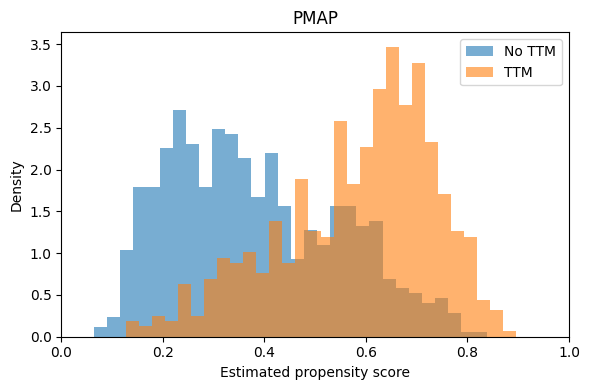

In [17]:
T_all = np.concatenate([T_train, T_test])
X_all = np.concatenate([myNewXTrain, myNewXTest])
ps_eicu, sum_eicu, flag_eicu, fig_eicu = run_propensity_diagnostics(
    causal_forest, T=T_all, X=X_all, W=None, dataset_name="PMAP"
)
print(sum_eicu)
print(flag_eicu)

In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2


def simulate_dataset_hte(
    n,
    treat_prev,
    subgroup_prev,
    baseline_risk,
    abs_treatment_effect=0.10,
    rng=None
):
    """
    Simulate binary outcomes with HTE present only in a latent subgroup.

    Parameters
    ----------
    n : int
        Sample size.
    treat_prev : float
        Treatment prevalence P(T=1).
    subgroup_prev : float
        Responsive subgroup prevalence P(G=1).
    baseline_risk : float
        Baseline outcome probability for untreated, non-subgroup patients.
    abs_treatment_effect : float
        Absolute treatment effect applied only within subgroup.
        Positive means benefit for a favorable outcome.
    rng : np.random.Generator or None

    Returns
    -------
    df : pd.DataFrame
        Simulated data with columns T, G, cate_score, Y
    """
    if rng is None:
        rng = np.random.default_rng()

    # Treatment assignment
    T = rng.binomial(1, treat_prev, size=n)

    # Latent subgroup that benefits
    G = rng.binomial(1, subgroup_prev, size=n)

    # True individual treatment effect:
    # only subgroup members benefit
    true_tau = abs_treatment_effect * G

    # Outcome probability
    # Here outcome is assumed favorable, so treatment increases probability
    p = baseline_risk + T * true_tau

    # keep probabilities in valid range
    p = np.clip(p, 1e-6, 1 - 1e-6)

    # Binary outcome
    Y = rng.binomial(1, p, size=n)

    # Oracle "CATE score"
    cate_score = true_tau

    return pd.DataFrame({
        "T": T,
        "G": G,
        "cate_score": cate_score,
        "Y": Y
    })

def lr_test_interaction(df):
    """
    Likelihood ratio test comparing:
      reduced: Y ~ T + cate_score
      full:    Y ~ T + cate_score + T:cate_score
    """
    X_reduced = pd.DataFrame({
        "const": 1.0,
        "T": df["T"],
        "cate_score": df["cate_score"]
    })

    X_full = pd.DataFrame({
        "const": 1.0,
        "T": df["T"],
        "cate_score": df["cate_score"],
        "interaction": df["T"] * df["cate_score"]
    })

    try:
        m0 = sm.Logit(df["Y"], X_reduced).fit(disp=False)
        m1 = sm.Logit(df["Y"], X_full).fit(disp=False)

        lr_stat = 2 * (m1.llf - m0.llf)
        df_diff = X_full.shape[1] - X_reduced.shape[1]
        pval = chi2.sf(lr_stat, df_diff)

        return {
            "lr_stat": lr_stat,
            "pval": pval,
            "converged": True
        }
    except Exception:
        return {
            "lr_stat": np.nan,
            "pval": np.nan,
            "converged": False
        }
def estimate_power_for_scenario(
    n,
    treat_prev,
    subgroup_prev,
    baseline_risk,
    abs_treatment_effect=0.10,
    n_sims=1000,
    alpha=0.05,
    seed=42
):
    rng = np.random.default_rng(seed)

    pvals = []
    n_fail = 0

    for _ in range(n_sims):
        df = simulate_dataset_hte(
            n=n,
            treat_prev=treat_prev,
            subgroup_prev=subgroup_prev,
            baseline_risk=baseline_risk,
            abs_treatment_effect=abs_treatment_effect,
            rng=rng
        )
        res = lr_test_interaction(df)
        if res["converged"] and np.isfinite(res["pval"]):
            pvals.append(res["pval"])
        else:
            n_fail += 1

    pvals = np.array(pvals)
    power = np.mean(pvals < alpha) if len(pvals) > 0 else np.nan

    return {
        "n": n,
        "treat_prev": treat_prev,
        "subgroup_prev": subgroup_prev,
        "baseline_risk": baseline_risk,
        "abs_treatment_effect": abs_treatment_effect,
        "n_sims": n_sims,
        "n_successful_fits": len(pvals),
        "n_failed_fits": n_fail,
        "power": power
    }
Y_all = np.concatenate([y_train, y_test])
baseline_risk = Y_all[T_all == 0].mean()
dataset_specs = {
    "eICU": {"n": T_all.shape[0], "treat_prev": T_all.mean(), "baseline_risk": 1-baseline_risk},
}

NameError: name 'T_all' is not defined

In [13]:
results = []

for ds, spec in dataset_specs.items():
    for subgroup_prev in [0.20, 0.30, 0.50]:
        out = estimate_power_for_scenario(
            n=spec["n"],
            treat_prev=spec["treat_prev"],
            subgroup_prev=subgroup_prev,
            baseline_risk=spec["baseline_risk"],
            abs_treatment_effect=0.15,
            n_sims=2000,
            alpha=0.05,
            seed=42
        )
        out["dataset"] = ds
        results.append(out)

power_table = pd.DataFrame(results)
power_table = power_table[[
    "dataset", "n", "treat_prev", "subgroup_prev",
    "baseline_risk", "abs_treatment_effect",
    "n_sims", "power", "n_failed_fits"
]]
power_table
import matplotlib.pyplot as plt

def plot_power_curves(power_table):
    fig, ax = plt.subplots(figsize=(7, 5))

    for ds, subdf in power_table.groupby("dataset"):
        subdf = subdf.sort_values("subgroup_prev")
        ax.plot(
            subdf["subgroup_prev"],
            subdf["power"],
            marker="o",
            label=ds
        )

    ax.set_xlabel("Responsive subgroup prevalence")
    ax.set_ylabel("Detection probability")
    ax.set_title("Simulation-based power for HTE detection")
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_power_curves(power_table)

NameError: name 'dataset_specs' is not defined

In [68]:
power_table

,dataset,n,treat_prev,subgroup_prev,baseline_risk,abs_treatment_effect,n_sims,power,n_failed_fits
0,eICU,1289,0.480217,0.2,0.680597,0.15,2000,0.7155,0
1,eICU,1289,0.480217,0.3,0.680597,0.15,2000,0.8390,0
2,eICU,1289,0.480217,0.5,0.680597,0.15,2000,0.9005,0


In [39]:
causal_forest.summary()

Population summary of CATE predictions on Training Data


[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done  88 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=25)]: Using backend ThreadingBackend with 25 concurrent workers.
[Parallel(n_jobs=25)]: Done   2 out of  25 | elapsed:    0.0s remaining:    0.5s
[Parallel(n_jobs=25)]: Done  15 out of  25 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=25)]: Done  25 out of  25 | elapsed:    0.1s finished


<class 'econml.utilities.Summary'>
"""
               Uncertainty of Mean Point Estimate               
================================================================
mean_point stderr_mean zstat  pvalue ci_mean_lower ci_mean_upper
----------------------------------------------------------------
    -0.032       0.089 -0.362  0.718        -0.206         0.142
      Distribution of Point Estimate     
=========================================
std_point pct_point_lower pct_point_upper
-----------------------------------------
    0.042          -0.119           0.057
     Total Variance of Point Estimate     
==========================================
stderr_point ci_point_lower ci_point_upper
------------------------------------------
       0.098         -0.232          0.166
        Doubly Robust ATE on Training Data Results       
=========================================================
    point_estimate stderr zstat  pvalue ci_lower ci_upper
---------------------------------------------------------
ATE         -0.022  0.036 -0.618  0.536   -0.094    0.049
     Doubly Robust ATT(T=0) on Training Data Results     
=========================================================
    point_estimate stderr zstat  pvalue ci_lower ci_upper
---------------------------------------------------------
ATT         -0.201  0.042 -4.759    0.0   -0.284   -0.118
    Doubly Robust ATT(T=1) on Training Data Results     
========================================================
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATT          0.171  0.059 2.912  0.004    0.056    0.286
--------------------------------------------------------

Note: The stderr_mean is a conservative upper bound.
"""

[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done  88 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:    0.0s finished


Optimization terminated successfully.
         Current function value: 0.540066
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.539896
         Iterations 6
Likelihood ratio of test results:
Chi square statistic: 0.306394746411911
p-value: 0.5799009856306234
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                  902
Model:                          Logit   Df Residuals:                      899
Method:                           MLE   Df Model:                            2
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                 0.03003
Time:                        15:16:20   Log-Likelihood:                -487.14
converged:                       True   LL-Null:                       -502.22
Covariance Type:            nonrobust   LLR p-value:                 2.815e-07
                       

np.float64(0.5799009856306234)

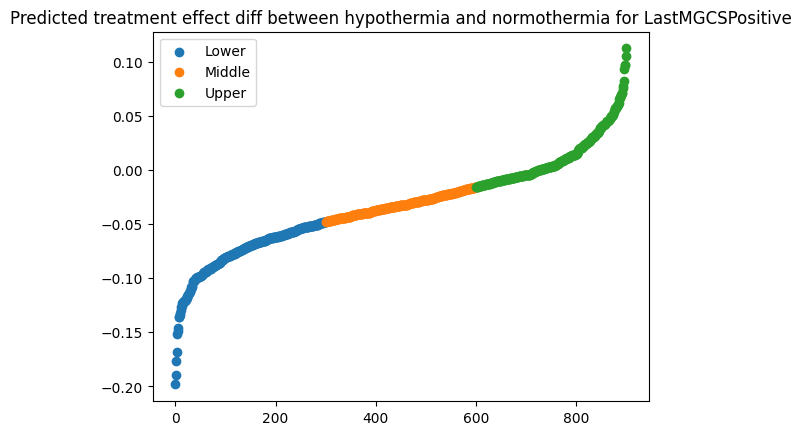

In [40]:
# myNewXTrain = pd.DataFrame(myPipeline.transform(X_train_no_group), columns = myPipeline.get_feature_names_out())
CATE_pred = causal_forest.effect(myNewXTrain)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
lower_third, upper_third, _ = getPredictedThirds(myNewDf)
plotPredictedTreatmentEffect(myNewDf, myPredicted)
# myNewDf['predicted_effect_group'] = (myNewDf['predicted_effect'] > 0).astype(str)

X_train_new = X_train_no_group.copy().reset_index()
X_train_new[myTreatment] = T_train.reset_index()[myTreatment]
y_train_df = pd.DataFrame()
y_train_df[myPredicted] = y_train.reset_index()[myPredicted]
getTreatmentEffectDiffDataFrame(X_train_new, y_train_df, myNewDf, myPredicted, myTreatment, False)

[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=25)]: Using backend ThreadingBackend with 25 concurrent workers.
[Parallel(n_jobs=25)]: Done   2 out of  25 | elapsed:    0.0s remaining:    0.3s
[Parallel(n_jobs=25)]: Done  15 out of  25 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=25)]: Done  25 out of  25 | elapsed:    0.0s finished


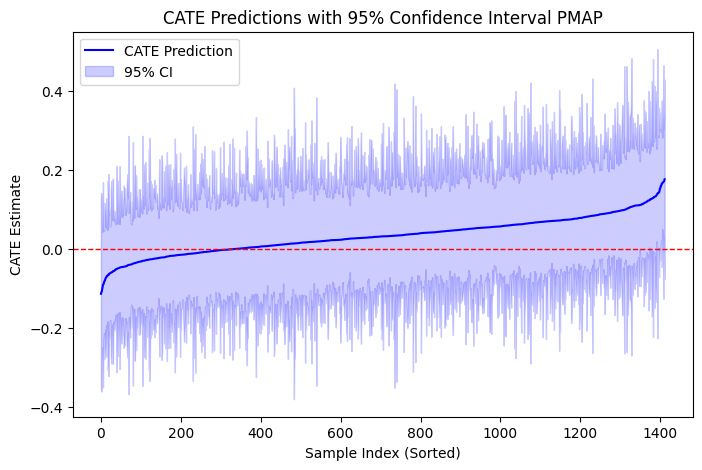

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Compute CATE prediction intervals
CATE_pred = causal_forest.effect(pd.concat([myNewXTrain, myNewXTest]))

cate_lower, cate_upper = causal_forest.effect_interval(pd.concat([myNewXTrain, myNewXTest]), alpha=0.05)

# Ensure arrays are 1D NumPy arrays
CATE_pred = np.array(CATE_pred).flatten()
cate_lower = np.array(cate_lower).flatten()
cate_upper = np.array(cate_upper).flatten()

# Sort values for a cleaner plot
sorted_idx = np.argsort(CATE_pred)
cate_pred_sorted = CATE_pred[sorted_idx]
cate_lower_sorted = cate_lower[sorted_idx]
cate_upper_sorted = cate_upper[sorted_idx]

# Create x-axis index
x = np.arange(len(cate_pred_sorted))

# Plot CATE predictions
plt.figure(figsize=(8, 5))
plt.plot(x, cate_pred_sorted, label='CATE Prediction', color='blue')

# Fill confidence interval
plt.fill_between(x, cate_lower_sorted, cate_upper_sorted, 
                 color='blue', alpha=0.2, label='95% CI')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
# Labels and title
plt.xlabel("Sample Index (Sorted)")
plt.ylabel("CATE Estimate")
plt.title("CATE Predictions with 95% Confidence Interval PMAP")
plt.legend()
plt.show()


[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done  88 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:    0.0s finished


Optimization terminated successfully.
         Current function value: 0.622169
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619876
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 1.9441612049388368
p-value: 0.16321742839520528
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:         death_at_disch   No. Observations:                  424
Model:                          Logit   Df Residuals:                      421
Method:                           MLE   Df Model:                            2
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                 0.02905
Time:                        15:17:09   Log-Likelihood:                -263.80
converged:                       True   LL-Null:                       -271.69
Covariance Type:            nonrobust   LLR p-value:                 0.0003733
                     

np.float64(0.16321742839520528)

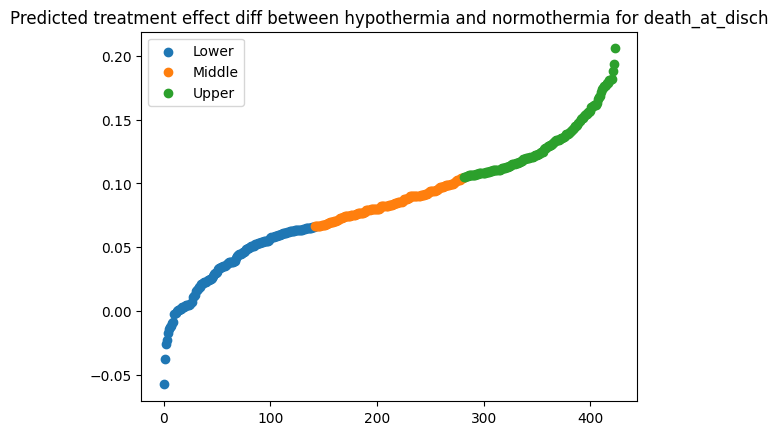

In [51]:
# myNewXTest = myPipeline.transform(X_test_no_group)
CATE_pred = causal_forest.effect(myNewXTest)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
lower_third, upper_third, _ = getPredictedThirds(myNewDf)
plotPredictedTreatmentEffect(myNewDf, myPredicted)
myNewDf['predicted_effect_group'] = (myNewDf['predicted_effect'] > 0).astype(str)


X_test_new = X_test_no_group.copy().reset_index()
X_test_new[myTreatment] = T_test.reset_index()[myTreatment]
y_test_df = pd.DataFrame()
y_test_df[myPredicted] = y_test.reset_index()[myPredicted]
getTreatmentEffectDiffDataFrame(X_test_new, y_test_df, myNewDf, myPredicted, myTreatment, False)